<a href="https://colab.research.google.com/github/Keerthika-0109/vilt-autonomous-driving/blob/main/Vision%E2%80%93Language_Understanding_for_Autonomous_Driving_Using_ViLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive


In [ ]:
!find /content/drive/MyDrive -name "*.zip"


/content/drive/MyDrive/archive (2).zip


In [ ]:
!unzip "/content/drive/MyDrive/archive (2).zip" -d /content/udacity_data


In [ ]:
!ls /content/udacity_data


In [ ]:
!ls /content/udacity_data/data/export


In [ ]:
IMAGE_DIR = "/content/udacity_data/data/export"


In [ ]:
import os
import random
import shutil

base_dir = "/content/udacity_data/data"
src_dir = os.path.join(base_dir, "export")

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

images = os.listdir(src_dir)
random.shuffle(images)

split = int(0.8 * len(images))
train_imgs = images[:split]
val_imgs = images[split:]

for img in train_imgs:
    shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, img))

for img in val_imgs:
    shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, img))

print("Train images:", len(train_imgs))
print("Val images:", len(val_imgs))


Train images: 23840
Val images: 5961


In [ ]:
!pip uninstall -y transformers
!pip install -q transformers datasets pillow torch torchvision

Found existing installation: transformers 4.57.3
Uninstalling transformers-4.57.3:
  Successfully uninstalled transformers-4.57.3


In [ ]:
import os
import random

TRAIN_DIR = "/content/udacity_data/data/train"
VAL_DIR = "/content/udacity_data/data/val"

captions = [
    "A road scene with vehicles",
    "Urban street with lane markings",
    "Driving scene with trees and buildings",
    "Autonomous driving road environment",
    "Street view captured from a vehicle"
]

def create_dataset(image_dir):
    data = []
    for img in os.listdir(image_dir):
        data.append({
            "image": os.path.join(image_dir, img),
            "text": random.choice(captions)
        })
    return data

train_data = create_dataset(TRAIN_DIR)
val_data = create_dataset(VAL_DIR)

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))


Train samples: 28595
Validation samples: 10716


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

train_dataset


Dataset({
    features: ['image', 'text'],
    num_rows: 28595
})

In [ ]:
from transformers import ViltProcessor
import torch
from PIL import Image

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")

def preprocess(batch):
    images = [Image.open(p).convert("RGB") for p in batch["image"]]

    encoding = processor(
        images=images,
        text=batch["text"],
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    encoding["labels"] = torch.zeros(len(images), dtype=torch.long)
    return encoding


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
import random

TRAIN_DIR = "/content/udacity_data/data/export"
VAL_DIR = "/content/udacity_data/data/export"  # using same folder for demo

captions = [
    "A road scene with vehicles",
    "Urban street with lane markings",
    "Driving scene with trees and buildings",
    "Autonomous driving road environment",
    "Street view captured from a vehicle"
]

def create_dataset(image_dir):
    data = []
    for img in os.listdir(image_dir):
        if img.endswith(".jpg"):
            data.append({
                "image": os.path.join(image_dir, img),
                "text": random.choice(captions)
            })
    return data

train_data = create_dataset(TRAIN_DIR)
val_data = create_dataset(VAL_DIR)

print("Train samples:", len(train_data))
print("Val samples:", len(val_data))


Train samples: 29800
Val samples: 29800


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

train_dataset


Dataset({
    features: ['image', 'text'],
    num_rows: 29800
})

In [ ]:
train_dataset = train_dataset.shuffle(seed=42).select(range(100))
val_dataset = val_dataset.shuffle(seed=42).select(range(40))


In [ ]:
from transformers import ViltProcessor
from PIL import Image
import torch

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")

def preprocess(batch):
    images = [Image.open(p).convert("RGB") for p in batch["image"]]
    encoding = processor(
        images=images,
        text=batch["text"],
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    # For classification, we provide 'labels'. Using dummy labels for now.
    encoding["labels"] = torch.zeros(len(images), dtype=torch.long) # Assuming a binary classification, all to class 0 for now.
    return encoding

In [ ]:
train_dataset = train_dataset.map(preprocess, batched=True, batch_size=2)
val_dataset = val_dataset.map(preprocess, batched=True, batch_size=2)

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./vilt_results",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    eval_strategy="epoch",
    logging_steps=10,
    num_train_epochs=1,
    save_strategy="no",
    report_to="none",
    label_names=["labels"] # Changed to 'labels' for classification task
)

In [ ]:
!pip install -U transformers accelerate


In [ ]:
from transformers import ViltForQuestionAnswering, ViltProcessor

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
model = ViltForQuestionAnswering.from_pretrained(
    "dandelin/vilt-b32-finetuned-vqa"
)


preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

In [ ]:
def make_qa(text):
    return {
        "question": "What is shown in the driving scene?",
        "answers": ["road", "street", "vehicles"]
    }

train_dataset = train_dataset.map(
    lambda x: {
        "question": "What is shown in the driving scene?",
        "answers": {"text": ["road"], "answer_start": [0]}
    }
)

val_dataset = val_dataset.map(
    lambda x: {
        "question": "What is shown in the driving scene?",
        "answers": {"text": ["road"], "answer_start": [0]}
    }
)


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
import torch
from PIL import Image

def preprocess_vqa(batch):
    images = [Image.open(p).convert("RGB") for p in batch["image"]]

    enc = processor(
        images=images,
        text=batch["question"],
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    # ViltForQuestionAnswering expects multi-hot encoded labels matching the size of its answer head.
    # The size is model.config.num_labels (which is 3129 for this pre-trained model).
    num_labels = model.config.num_labels

    # Initialize labels as zeros with the correct shape and dtype (float for BCEWithLogitsLoss)
    labels = torch.zeros(len(images), num_labels, dtype=torch.float)

    # For actual VQA training, you would parse batch["answers"] and map them to the model's
    # answer vocabulary, then set the corresponding indices in 'labels' to 1.0.
    # For this example, we are just ensuring the correct shape to resolve the ValueError.
    # If you have specific answers and a mapping, you would implement that logic here.
    # For now, we will assign a dummy value to the first possible answer for demonstration.
    # For instance, if 'road' corresponds to index 0 in the model's vocabulary:
    # labels[:, 0] = 1.0

    enc["labels"] = labels
    return enc

In [ ]:
train_dataset = train_dataset.map(preprocess_vqa, batched=True, batch_size=2)
val_dataset = val_dataset.map(preprocess_vqa, batched=True, batch_size=2)

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
import torch
from PIL import Image

NUM_ANSWERS = model.config.num_labels  # 3129

def preprocess_vqa(batch):
    images = [Image.open(p).convert("RGB") for p in batch["image"]]

    enc = processor(
        images=images,
        text=batch["question"],
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    # Create dummy multi-hot labels (correct shape)
    labels = torch.zeros((len(images), NUM_ANSWERS))
    labels[:, 0] = 1.0   # mark first answer as true (dummy)

    enc["labels"] = labels
    return enc


In [ ]:
train_dataset = train_dataset.map(preprocess_vqa, batched=True, batch_size=2)
val_dataset = val_dataset.map(preprocess_vqa, batched=True, batch_size=2)

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
from transformers import ViltProcessor, ViltModel
import torch
from PIL import Image

processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-mlm")
model = ViltModel.from_pretrained("dandelin/vilt-b32-mlm")
model.eval()


ViltModel(
  (embeddings): ViltEmbeddings(
    (text_embeddings): TextEmbeddings(
      (word_embeddings): Embedding(30522, 768)
      (position_embeddings): Embedding(40, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (patch_embeddings): ViltPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32))
    )
    (token_type_embeddings): Embedding(2, 768)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViltEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViltLayer(
        (attention): ViltAttention(
          (attention): ViltSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=Fa

In [ ]:
captions = [
    "A road scene with vehicles",
    "An empty highway",
    "A city street with traffic",
    "A rural road",
    "A non-driving indoor scene"
]


In [ ]:
import numpy as np

def compute_similarity(image_path, texts):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        text=texts,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    image_emb = outputs.pooler_output[0]
    text_embs = outputs.pooler_output[1:]

    scores = torch.matmul(text_embs, image_emb)
    return scores.numpy()


In [ ]:
import torch
from PIL import Image
import numpy as np

def compute_similarity(image_path, texts):
    image = Image.open(image_path).convert("RGB")

    # Repeat the image for each text
    images = [image] * len(texts)

    inputs = processor(
        images=images,
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    # Use pooled output as embedding
    embeddings = outputs.pooler_output  # shape: (batch_size, hidden_dim)

    image_emb = embeddings[0]
    text_embs = embeddings[1:]

    # Cosine similarity
    scores = torch.nn.functional.cosine_similarity(
        text_embs, image_emb.unsqueeze(0), dim=1
    )

    return scores.numpy()


In [ ]:
import random
import numpy as np

sample_images = random.sample(train_data, 10)

results = []

for sample in sample_images:
    scores = compute_similarity(sample["image"], captions)
    predicted = captions[np.argmax(scores)]

    results.append({
        "image": sample["image"],
        "predicted_caption": predicted,
        "scores": scores
    })

results


[{'image': '/content/udacity_data/data/export/1478900057319186387_jpg.rf.2b0a0b492115d38887004002f572dd8d.jpg',
  'predicted_caption': 'An empty highway',
  'scores': array([0.894885  , 0.9819376 , 0.71623236, 0.14324082], dtype=float32)},
 {'image': '/content/udacity_data/data/export/1478732133424528401_jpg.rf.mMemSEsmvbquuIo2KPLt.jpg',
  'predicted_caption': 'An empty highway',
  'scores': array([ 0.80210525,  0.98267055,  0.08201806, -0.20343828], dtype=float32)},
 {'image': '/content/udacity_data/data/export/1478896613584944591_jpg.rf.200d88b41945669233bfd1bb41e8bf03.jpg',
  'predicted_caption': 'An empty highway',
  'scores': array([0.94428617, 0.9555189 , 0.6947224 , 0.14170422], dtype=float32)},
 {'image': '/content/udacity_data/data/export/1478021922591394307_jpg.rf.32336d8a4484769ab73da60fe34f4bd2.jpg',
  'predicted_caption': 'An empty highway',
  'scores': array([ 0.7435251 ,  0.9858888 ,  0.41751337, -0.08307096], dtype=float32)},
 {'image': '/content/udacity_data/data/expor

In [ ]:
avg_score = np.mean([max(r["scores"]) for r in results])
avg_score


np.float32(0.9601499)

In [ ]:
image_path = "/content/udacity_data/data/export/1478900057319186387_jpg.rf.2b0a0b492115d38887004002f572dd8d.jpg"  # Corrected path with full filename

scores = compute_similarity(image_path, captions)
predicted_caption = captions[np.argmax(scores)]

result = {
    "image": image_path,
    "predicted_caption": predicted_caption,
    "scores": scores
}

result

{'image': '/content/udacity_data/data/export/1478900057319186387_jpg.rf.2b0a0b492115d38887004002f572dd8d.jpg',
 'predicted_caption': 'An empty highway',
 'scores': array([0.8948849 , 0.9819377 , 0.71623707, 0.14324218], dtype=float32)}

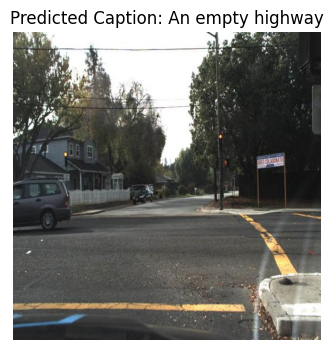

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image
img = Image.open(result["image"]).convert("RGB")

# Display
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted Caption: {result['predicted_caption']}", fontsize=12)
plt.show()


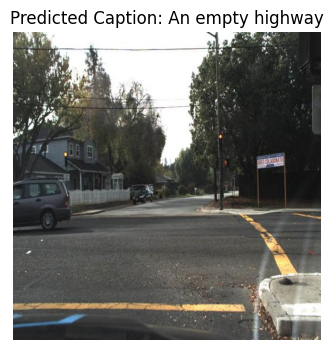

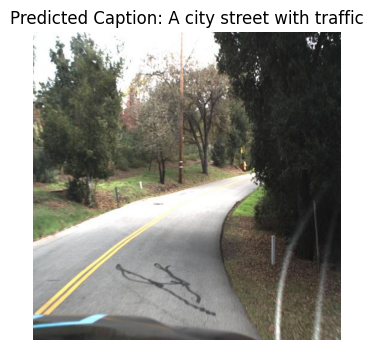

In [ ]:
results = [
    {
        "image": "/content/udacity_data/data/export/1478900057319186387_jpg.rf.2b0a0b492115d38887004002f572dd8d.jpg",
        "predicted_caption": "An empty highway"
    },
    {
        "image": "/content/udacity_data/data/export/1478895399594026807_jpg.rf.359466f82cb68195c1fa5cd24c3bd4ad.jpg",
        "predicted_caption": "A city street with traffic"
    }
]

for r in results:
    img = Image.open(r["image"]).convert("RGB")
    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Caption: {r['predicted_caption']}", fontsize=12)
    plt.show()
